<a href="https://colab.research.google.com/github/MdShajalalsojib/Machine-Learning-Lab/blob/main/ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow

In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models

In [3]:
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


In [4]:
X_train.shape[0]+X_test.shape[0]

60000

In [5]:
import matplotlib.pyplot as plt

In [6]:
categories = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

Text(0.5, 1.0, 'frog')

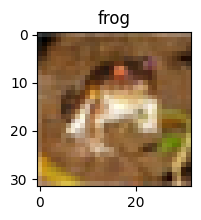

In [7]:
plt.figure(figsize=(2,2))
plt.imshow(X_train[0])
plt.title(categories[y_train.reshape(-1)[0]])

In [8]:
# normalization

X_train = X_train/255
X_test = X_test/255

In [9]:
X_train[0]

array([[[0.23137255, 0.24313725, 0.24705882],
        [0.16862745, 0.18039216, 0.17647059],
        [0.19607843, 0.18823529, 0.16862745],
        ...,
        [0.61960784, 0.51764706, 0.42352941],
        [0.59607843, 0.49019608, 0.4       ],
        [0.58039216, 0.48627451, 0.40392157]],

       [[0.0627451 , 0.07843137, 0.07843137],
        [0.        , 0.        , 0.        ],
        [0.07058824, 0.03137255, 0.        ],
        ...,
        [0.48235294, 0.34509804, 0.21568627],
        [0.46666667, 0.3254902 , 0.19607843],
        [0.47843137, 0.34117647, 0.22352941]],

       [[0.09803922, 0.09411765, 0.08235294],
        [0.0627451 , 0.02745098, 0.        ],
        [0.19215686, 0.10588235, 0.03137255],
        ...,
        [0.4627451 , 0.32941176, 0.19607843],
        [0.47058824, 0.32941176, 0.19607843],
        [0.42745098, 0.28627451, 0.16470588]],

       ...,

       [[0.81568627, 0.66666667, 0.37647059],
        [0.78823529, 0.6       , 0.13333333],
        [0.77647059, 0

In [10]:
X_train[0].shape

(32, 32, 3)

In [13]:
# neural network

ann = models.Sequential(
    [
        layers.Flatten(input_shape=(2,2,1)),
        layers.Dense(3,activation='relu'),
        layers.Dense(1,activation='relu'),
        layers.Dense(1,activation='sigmoid')
    ]
)

ann.compile(
    optimizer='SGD',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = ann.fit(X_train, y_train, epochs=20)

Epoch 1/20


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 with name 'None' of layer 'dense_6' is incompatible with the layer: expected axis -1 of input shape to have value 4, but received input with shape (None, 3072)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, 32, 32, 3), dtype=float32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [14]:
loss, accuracy = ann.evaluate(X_test, y_test)

ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 with name 'None' of layer 'dense_6' is incompatible with the layer: expected axis -1 of input shape to have value 4, but received input with shape (None, 3072)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, 32, 32, 3), dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [15]:
plt.plot(range(1,21),history.history['accuracy'])

NameError: name 'history' is not defined

In [ ]:
y_predict = ann.predict(X_test)

In [ ]:
import numpy as np
np.argmax(y_predict[0]), y_test[0]

In [ ]:
y_test

In [ ]:
y_predict = [np.argmax(i) for i in y_predict]

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_predict,y_test))